In [6]:
import numpy as np
import pandas as pd
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

In [8]:
re = np.array([0.05, 0.085, 0.075, 0.095, 0.065, 0.005, 0.025, 0.045, 0.065, 0.055]) #
ri = np.array([0.18, 0.195, 0.185, 0.20, 0.23, 0.03, 0.09, 0.16, 0.19, 0.15])

In [3]:
import numpy as np
from pymoo.core.problem import Problem

class MyProblem(Problem):
    def __init__(self):
        super().__init__(
            n_var=10,    # 設計変数の数：10個の資産の比率
            n_obj=2,     # 目的関数の数：リターン最大化とリスク最小化
            n_constr=1,  # 制約条件の数：合計比率 = 100%
            xl=0.0,      # 各資産の最小比率（0%）
            xu=1.0       # 各資産の最大比率（100%）
        )

    def _evaluate(self, x, out, *args, **kwargs):
        # x は (個体数, 10) の行列

        # 目的関数1：ポートフォリオ全体の期待リターン（のマイナス）
        # 各資産の比率 * 期待リターンの合計
        f1 = -np.sum(x * re, axis=1)

        # 目的関数2：ポートフォリオ全体の推定リスク（分散）
        # 各資産の比率の2乗 * リスクの2乗（簡易モデル：相関なしと仮定）
        f2 = np.sum((x**2) * (ri**2), axis=1)

        # 制約条件：合計比率が1.0であること
        # pymooでは「g(x) <= 0」の形式で記述するため、abs(sum - 1) = 0 を目指す
        g1 = np.abs(np.sum(x, axis=1) - 1.0) - 0.1

        out["F"] = np.column_stack([f1, f2])
        out["G"] = g1

In [4]:
# 最適化の実行
problem   = MyProblem()
algorithm = NSGA2(pop_size=100)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 300),
    seed=42,
    verbose=False
)

パレート最適解の数: 100
    リターン      リスク
0.085797 0.008968
0.035238 0.001173
0.042732 0.001581
0.045183 0.001757
0.065847 0.003884
0.083660 0.008409
0.083519 0.007993
0.039336 0.001375
0.064812 0.003700
0.073317 0.004900


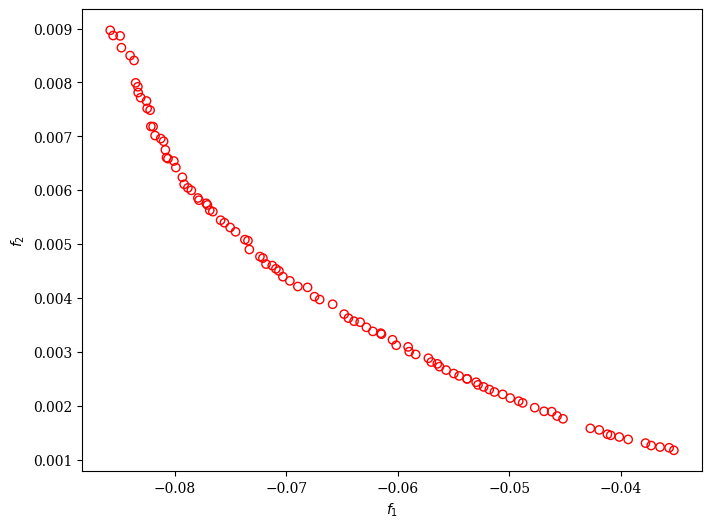

In [7]:
##結果の表示
print(f"パレート最適解の数: {len(res.F)}")

amout=1000000

df = pd.DataFrame({
    "リターン": -res.F[:, 0],
    "リスク": res.F[:, 1],
})


mean_return=np.mean(-res.F[:, 0])
mean_risk=np.std(res.F[:, 1])



print(df.head(10).to_string(index=False))

# パレートフロントの描画
plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.show()

In [14]:
print(re)
print(ri)
mean_return=np.mean(-res.F[:, 0])
mean_risk=np.std(res.F[:, 1])
print(mean_return,mean_risk)

[0.05  0.085 0.075 0.095 0.065 0.005 0.025 0.045 0.065 0.055]
[0.18  0.195 0.185 0.2   0.23  0.03  0.09  0.16  0.19  0.15 ]
0.06528386698891861 0.002223931832581794


In [71]:
problem   = MyProblem()

repeat=50

y=[]
X=[]
for i in list(range(0,repeat)):
    algorithm = NSGA2(pop_size=100)
    res=minimize(
        problem,
        algorithm,
        ('n_gen', 300),
        seed=i,
        verbose=False
    )
    c = np.hstack((re,ri))
    X.append(c)
    mean_return=np.mean(-res.F[:, 0])
    mean_isk=np.std(res.F[:, 1])

    y.append([mean_return,mean_risk])
print(y)

[[np.float64(0.06619203681887391), np.float64(0.002223931832581794)], [np.float64(0.06681372337721148), np.float64(0.002223931832581794)], [np.float64(0.06143809317703168), np.float64(0.002223931832581794)], [np.float64(0.06251795638025412), np.float64(0.002223931832581794)], [np.float64(0.06001866454630756), np.float64(0.002223931832581794)], [np.float64(0.06687837451211805), np.float64(0.002223931832581794)], [np.float64(0.06437721593188811), np.float64(0.002223931832581794)], [np.float64(0.0666476355167886), np.float64(0.002223931832581794)], [np.float64(0.06344575769926651), np.float64(0.002223931832581794)], [np.float64(0.06291241881822192), np.float64(0.002223931832581794)], [np.float64(0.061468660018245976), np.float64(0.002223931832581794)], [np.float64(0.06609930770106306), np.float64(0.002223931832581794)], [np.float64(0.06421034156607396), np.float64(0.002223931832581794)], [np.float64(0.06449661181589622), np.float64(0.002223931832581794)], [np.float64(0.06186290741491342),

In [73]:
print(X,y)

[array([0.05 , 0.085, 0.075, 0.095, 0.065, 0.005, 0.025, 0.045, 0.065,
       0.055, 0.18 , 0.195, 0.185, 0.2  , 0.23 , 0.03 , 0.09 , 0.16 ,
       0.19 , 0.15 ]), array([0.05 , 0.085, 0.075, 0.095, 0.065, 0.005, 0.025, 0.045, 0.065,
       0.055, 0.18 , 0.195, 0.185, 0.2  , 0.23 , 0.03 , 0.09 , 0.16 ,
       0.19 , 0.15 ]), array([0.05 , 0.085, 0.075, 0.095, 0.065, 0.005, 0.025, 0.045, 0.065,
       0.055, 0.18 , 0.195, 0.185, 0.2  , 0.23 , 0.03 , 0.09 , 0.16 ,
       0.19 , 0.15 ]), array([0.05 , 0.085, 0.075, 0.095, 0.065, 0.005, 0.025, 0.045, 0.065,
       0.055, 0.18 , 0.195, 0.185, 0.2  , 0.23 , 0.03 , 0.09 , 0.16 ,
       0.19 , 0.15 ]), array([0.05 , 0.085, 0.075, 0.095, 0.065, 0.005, 0.025, 0.045, 0.065,
       0.055, 0.18 , 0.195, 0.185, 0.2  , 0.23 , 0.03 , 0.09 , 0.16 ,
       0.19 , 0.15 ]), array([0.05 , 0.085, 0.075, 0.095, 0.065, 0.005, 0.025, 0.045, 0.065,
       0.055, 0.18 , 0.195, 0.185, 0.2  , 0.23 , 0.03 , 0.09 , 0.16 ,
       0.19 , 0.15 ]), array([0.05 , 0.085, 

In [74]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import numpy as np


# 1. データの準備（お手元のデータを代入してください）
# X: shape(50, 10), y: shape(50, 2) を想定

X_data = np.array(X, dtype=np.float32)
y_data = np.array(y, dtype=np.float32)

# 標準化（これだけは精度を出すために必須です）
scaler_X, scaler_y = StandardScaler(), StandardScaler()
X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

# テンソル変換
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

# 2. 最もシンプルなモデル定義 (入力10 -> 隠れ層32 -> 出力2)
model = nn.Sequential(
    nn.Linear(20, 32), # ★ここを「20」にする
    nn.ReLU(),
    nn.Linear(32, 2)
)

# 3. 誤差関数と最適化の手法
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. 学習（500回まわす）
for epoch in range(500):
    optimizer.zero_grad()
    hypothesis = model(X_tensor)
    loss = criterion(hypothesis, y_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/500, Loss: {loss.item():.6f}")

print("学習完了！")

Epoch 100/500, Loss: 0.500000
Epoch 200/500, Loss: 0.500000
Epoch 300/500, Loss: 0.500000
Epoch 400/500, Loss: 0.500000
Epoch 500/500, Loss: 0.500000
学習完了！



--- 予測結果の確認（最初の5件） ---
データ 1 | 正解: [0.06619204 0.00222393], 予測: [0.06498567 0.00222393]
データ 2 | 正解: [0.06681372 0.00222393], 予測: [0.06498567 0.00222393]
データ 3 | 正解: [0.06143809 0.00222393], 予測: [0.06498567 0.00222393]
データ 4 | 正解: [0.06251796 0.00222393], 予測: [0.06498567 0.00222393]
データ 5 | 正解: [0.06001867 0.00222393], 予測: [0.06498567 0.00222393]


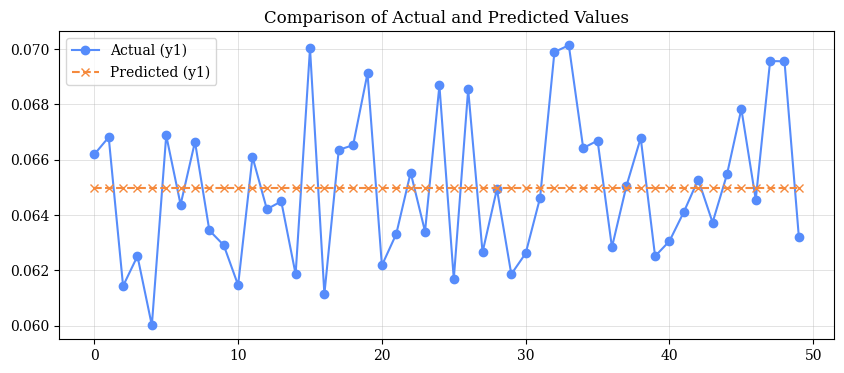

In [75]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# ステップ1: モデルを評価モードにし、勾配計算をオフにする
# --------------------------------------------------
model.eval()

with torch.no_grad():
    # 今回は学習に使ったデータをそのままモデルに入力して予測値を出してみます
    y_pred_scaled = model(X_tensor).numpy()

# --------------------------------------------------
# ステップ2: 標準化された予測値を「元の単位（スケール）」に復元する
# --------------------------------------------------
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# 比較のために、正解データ（y_data）の実際の値と予測値を並べて表示
print("\n--- 予測結果の確認（最初の5件） ---")
for i in range(5):
    print(f"データ {i+1} | 正解: {y_data[i]}, 予測: {y_pred[i]}")

# --------------------------------------------------
# ステップ3: グラフで視覚的に確かめる（オプション）
# --------------------------------------------------
# 出力 y の1つ目の変数について、正解と予測をプロット
plt.figure(figsize=(10, 4))
plt.plot(y_data[:, 0], label='Actual (y1)', marker='o')
plt.plot(y_pred[:, 0], label='Predicted (y1)', marker='x', linestyle='--')
plt.title('Comparison of Actual and Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. データの準備
# お手元のデータを [50, 10] と [50, 2] の形状のNumPy配列にしてください
# 例: X_データが (50, 10), Y_データが (50, 2)
X = np.array(X_list, dtype=np.float32)  # 形状: (50, 10)
y = np.array(y_list, dtype=np.float32)  # 形状: (50, 2)

# データの標準化（データ数が少ないときは特に重要です）
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# PyTorchのテンソルに変換
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)


# 2. サロゲートモデルの定義
class SmallSurrogateModel(nn.Module):
    def __init__(self):
        super(SmallSurrogateModel, self).__init__()
        # データ数が50件と少ないため、層を深くしすぎず、ニューロン数も少し抑えます
        self.network = nn.Sequential(
            nn.Linear(10, 32),
            nn.ReLU(),
            nn.Dropout(0.1), # 過学習を防ぐために10%のニューロンをランダムに無効化
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)  # 出力は2次元
        )

    def forward(self, x):
        return self.network(x)

model = SmallSurrogateModel()


# 3. 損失関数と最適化手法の設定
criterion = nn.MSELoss()  # 平均二乗誤差
# データ数が少ないため、学習率(lr)は少し小さめ（0.005〜0.001）からスタート
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4) # weight_decayで過学習を抑制


# 4. モデルの学習ループ
epochs = 1000  # データが少ない分、しっかり回します

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # 50件なので、ミニバッチに分けず一括（フルバッチ）で学習させます
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)

    loss.backward()
    optimizer.step()

    # 200エポックごとに誤差を表示
    if (epoch + 1) % 200 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

print("学習完了！")

NameError: name 'X_list' is not defined